In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')


### Data Load

In [3]:
image_transforms=transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,    
        contrast=0.2,      
        saturation=0.2,    
        hue=0.05           
    ),
    transforms.RandomAffine(
    degrees=10,          
    translate=(0.1, 0.1), 
    scale=(0.9, 1.1),     
    shear=10              
     ),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
      ])

 Standard ImageNet Normalization Values (RGB) are transform.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
                    

In [4]:
dataset_path='./dataset'
dataset=datasets.ImageFolder(dataset_path,transform=image_transforms)
len(dataset)

2300

In [5]:
print(dataset.classes)
num_classes=len(dataset.classes)
print(f'number of classes:{num_classes}')

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']
number of classes:6


In [6]:
train_size=int(0.75*len(dataset))
val_size=int(len(dataset)-train_size)
print(f'Training size:{train_size}')
print(f'Test size:{val_size}')

Training size:1725
Test size:575


In [7]:
from torch.utils.data import random_split
train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

In [8]:
train_loader=DataLoader(train_dataset,batch_size= 32,shuffle= True)
val_loader=DataLoader(val_dataset,batch_size= 32,shuffle= True)

In [9]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [10]:
images[0].shape,labels.shape

(torch.Size([3, 224, 224]), torch.Size([32]))

Batch_size= 32,RGB channel-->3,image size(224,224)

In [11]:
images[0].squeeze().shape

torch.Size([3, 224, 224])

In [12]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

permute is used to change dimension of image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.169412].


tensor(1)


'F_Breakage'

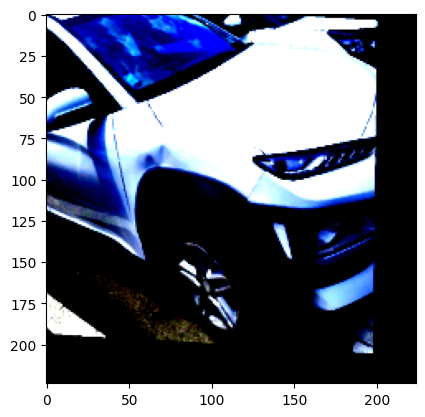

In [13]:
plt.imshow(images[31].permute(1,2,0))
plt.show
print(labels[31])
dataset.classes[0]

### Model:CNN

In [14]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super(). __init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels= 3,out_channels= 16,kernel_size=(3,3),stride= 1,padding= 1),  ### O/P: (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2),stride= (2,2)), ### O/P: (16,112,112)
            nn.Conv2d(in_channels= 16,out_channels= 32,kernel_size=(3,3),stride= 1,padding= 1),  ### O/P: (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)), ### O/P: (32,56,56)
            nn.Conv2d(in_channels= 32,out_channels= 64,kernel_size=(3,3),stride= 1,padding= 1),  ### O/P: (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)), ### O/P: (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
            
            )

    def forward(self,x):
        x=self.network(x)
        return x
        

In [15]:

model=CarClassifierCNN(num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [16]:
images.size(0)

32

In [17]:
len(train_loader.dataset)

1725

In [19]:
def train_model(model, criterion, optimizer, num_epochs=5):
    start = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            if (batch_num + 1) % 10 == 0:
                print(f'Batch {batch_num + 1}, Epoch {epoch + 1}, Loss: {loss.item():.2f}')

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch + 1}/{num_epochs}, Avg Loss: {epoch_loss:.4f}')

    # Validation after all epochs
    model.eval()
    total_predictions = 0
    correct_predictions = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

        accuracy = 100 * correct_predictions / total_predictions
        print(f'Validation Accuracy: {accuracy:.2f}%')

    end = time.time()
    print(f'Execution time: {end - start:.2f} seconds')

    return all_labels, all_predictions

            
            
            
            
            

In [ ]:
all_labels,all_predictions=train_model(model,criterion,optimizer,num_epochs=5)

In [20]:
2802%60


42

### Model2 CNN with Regularization

In [22]:
class CarClassifierCNNRegularization(nn.Module):
    def __init__(self, num_classes):
        super(). __init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels= 3,out_channels= 16,kernel_size=(3,3),stride= 1,padding= 1),  ### O/P: (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2),stride= (2,2)), ### O/P: (16,112,112)
            nn.Conv2d(in_channels= 16,out_channels= 32,kernel_size=(3,3),stride= 1,padding= 1),  ### O/P: (32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)), ### O/P: (32,56,56)
            nn.Conv2d(in_channels= 32,out_channels= 64,kernel_size=(3,3),stride= 1,padding= 1),  ### O/P: (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)), ### O/P: (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,num_classes)
            
            )

    def forward(self,x):
        x=self.network(x)
        return x
        

In [ ]:
model = CarClassifierCNNRegularization(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
all_labels,all_predictions=train_model(model,criterion,optimizer,num_epochs=5)

### Model3 Transfer Learning with EfficientNet

In [30]:
model_1=models.efficientnet_b0(weights='DEFAULT')
model_1.classifier[1].in_features

1280

In [35]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self,num_classes):
        super(). __init__()
        self.model=models.efficientnet_b0(weights='DEFAULT')
        for param in self.model.parameters():  #Freezing all layers
            param.requires_grad=False
        in_features=self.model.classifier[1].in_features
         
        self.model.classifier=nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features,num_classes)
        )

    def forward(self,x):
        x=self.model(x)
        return x
        

In [ ]:
model = CarClassifierEfficientNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad,model.parameters()), lr=0.001, weight_decay=1e-4) #using parameters when requires grad
all_labels,all_predictions=train_model(model,criterion,optimizer,num_epochs=5)

### Model4 Transfer Learner Resnet

In [38]:
model_2=models.resnet50(weights='DEFAULT')
model_2.fc.in_features

2048

In [20]:
class CarClassifierResNet(nn.Module):
    def __init__(self,num_classes):
        super(). __init__()
        self.model=models.resnet50(weights='DEFAULT')
        # Freeze all layers 
        for param in self.model.parameters():
            param.requires_grad= False
        #Unfreezing 4th layer
        for param in self.model.layer4.parameters():
            param.requires_grad= True

            
        in_features=self.model.fc.in_features
         
        self.model.fc=nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features,num_classes)
        )

    def forward(self,x):
        x=self.model(x)
        return x
        

In [ ]:
model = CarClassifierResNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad,model.parameters()), lr=0.001, weight_decay=1e-4) #using parameters when requires grad
all_labels,all_predictions=train_model(model,criterion,optimizer,num_epochs=10)

### Model Evaluation and Model export

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
report=classification_report(all_labels,all_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       131
           1       0.73      0.77      0.75       107
           2       0.95      0.78      0.86       103
           3       0.73      0.68      0.71        72
           4       0.69      0.80      0.74        83
           5       0.84      0.75      0.79        79

    accuracy                           0.79       575
   macro avg       0.79      0.78      0.78       575
weighted avg       0.79      0.79      0.79       575



In [30]:
class_names=dataset.classes

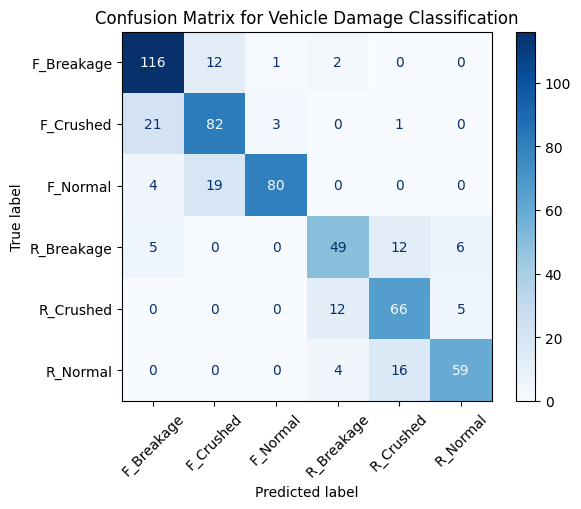

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(all_labels, all_predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [28]:
torch.save(model.state_dict(),'saved_model.pth')